# Wine Quality Prediction

## Objective
Predict wine quality using physicochemical properties and compare
Random Forest, SGD Classifier, and Support Vector Classifier models.

## Models Used
1. Random Forest
2. SGD Classifier
3. Support Vector Classifier (SVC)

# Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [2]:
df = pd.read_csv("C:/Users/asind/Downloads/L2-Task 2/archive (5)/WineQT.csv", sep=",")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# Inspect the dataset

In [3]:
df.shape

(1143, 13)

In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# Check missing values

In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

# Check duplicate records

In [8]:
df.duplicated().sum()

np.int64(0)

# Understand the target variable

In [9]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


In [10]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [11]:
df = df.drop(columns=["Id"])

In [12]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [13]:
df.shape

(1143, 12)

In [14]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [15]:
df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

# Visualize the quality distribution

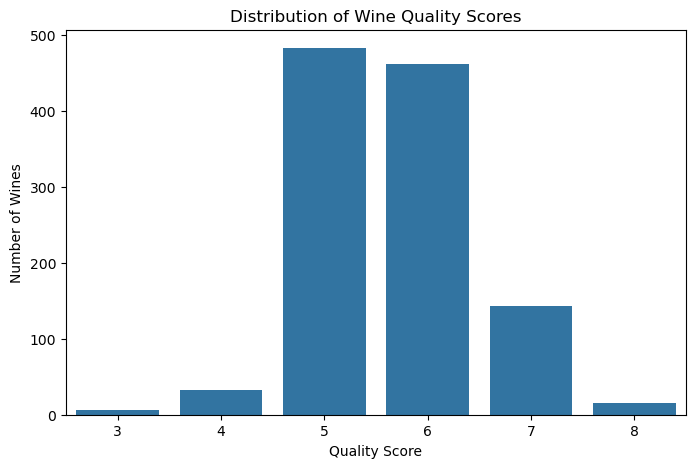

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.show()

# Calculate the percentages

In [17]:
quality_percentage = (
    df["quality"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(quality_percentage.round(2))

quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: proportion, dtype: float64


## Class Imbalance
The wine quality dataset is highly imbalanced. Quality scores 5 and 6 represent the majority of the observations, while quality scores 3 and 8 contain very few samples. This imbalance can cause classification models to favor the majority classes and perform poorly when predicting minority classes. Therefore, accuracy alone is not sufficient for evaluating the models. Precision, recall, F1-score and confusion matrices will also be considered.

# EDA: Distribution of chemical features

In [18]:
features = df.drop(columns=["quality"]).columns

print(features)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


# Plot chemical feature distributions

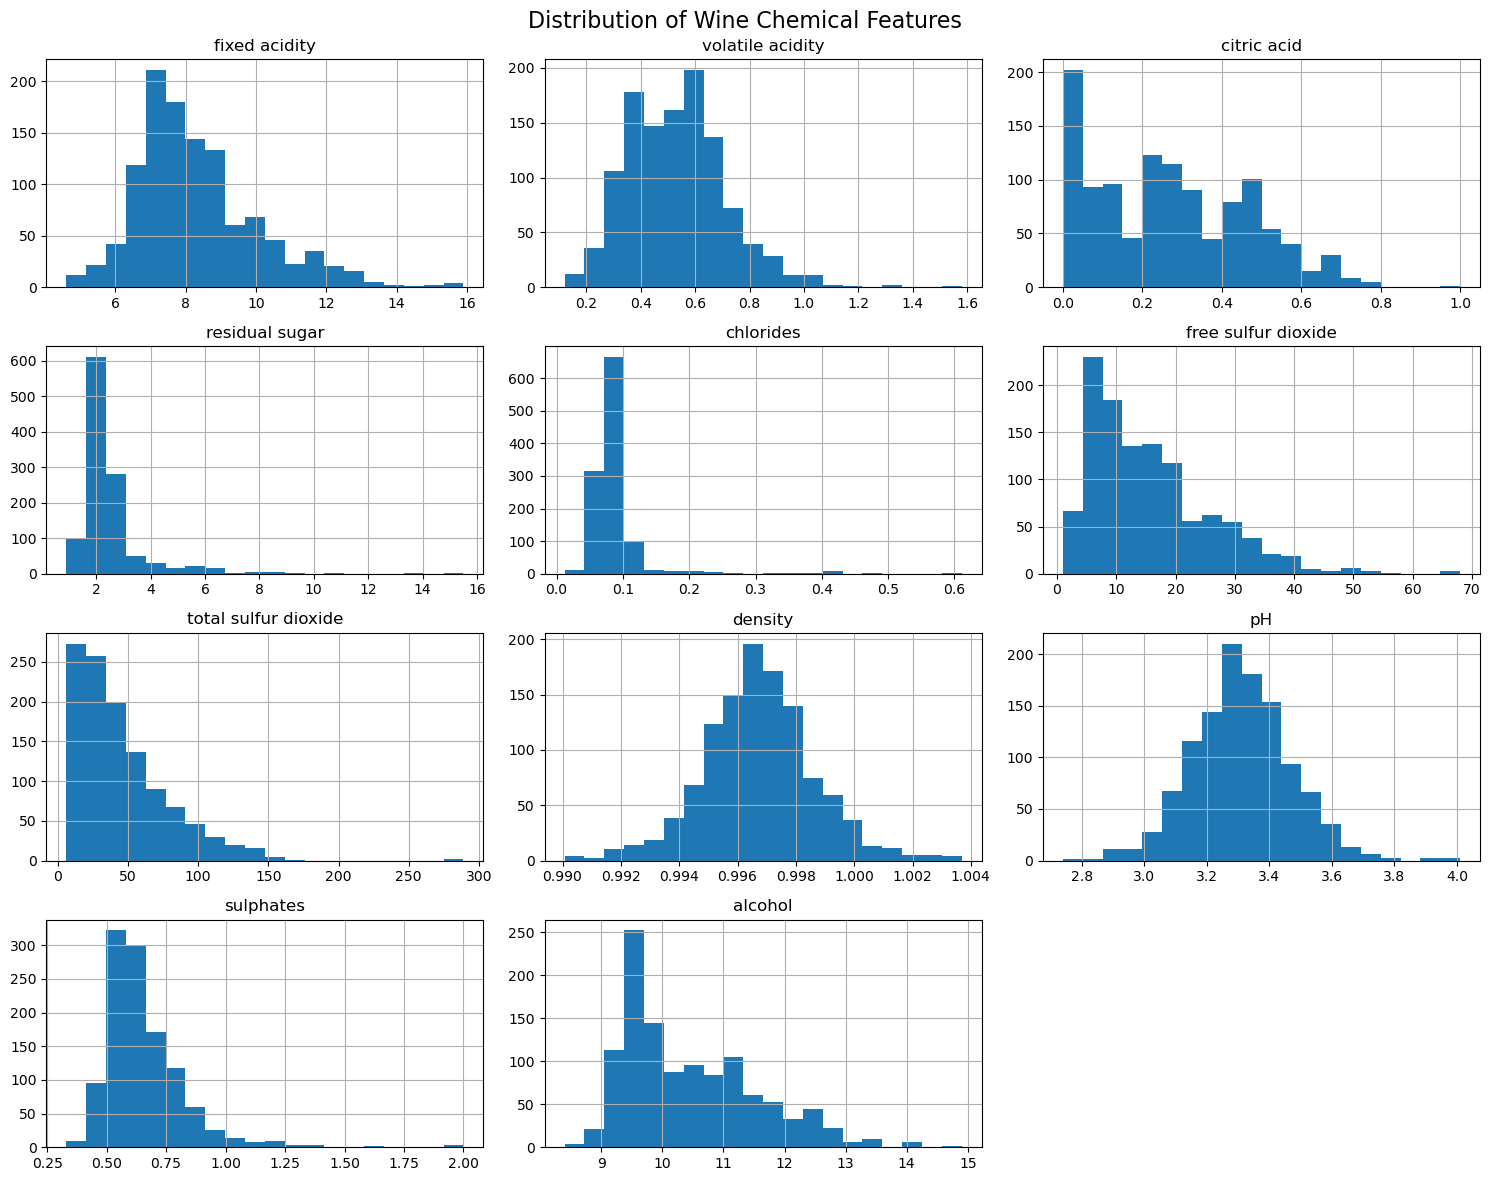

In [19]:
df[features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Wine Chemical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Boxplot

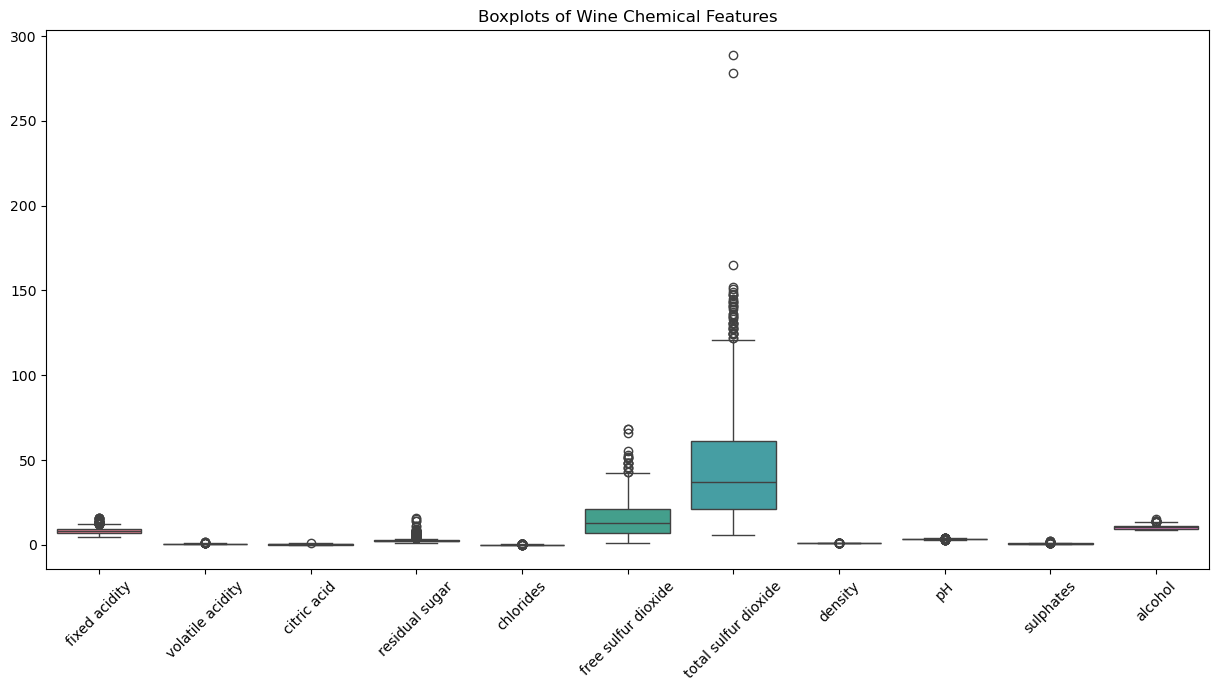

In [20]:
plt.figure(figsize=(15, 7))

sns.boxplot(data=df[features])

plt.xticks(rotation=45)
plt.title("Boxplots of Wine Chemical Features")

plt.show()

# Correlation heatmap

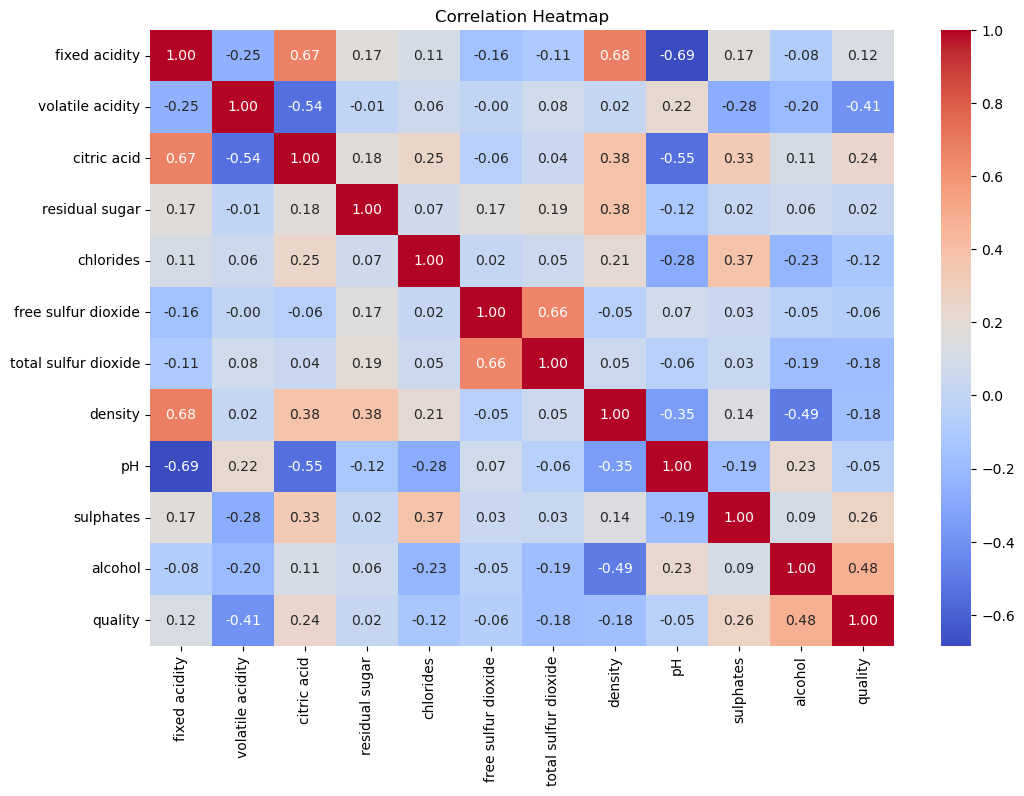

In [21]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation with quality

In [22]:
quality_corr = df.corr()["quality"].sort_values(
    ascending=False
)

print(quality_corr)

quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


## Correlation Analysis

The correlation matrix shows the relationships between the physicochemical properties and wine quality. Some features have positive relationships with quality, while others have negative relationships. However, correlation measures linear association and does not necessarily imply causation. The machine learning models will consider the features together rather than relying on individual correlations.

# Create the new target

In [23]:
def quality_category(quality):
    if quality <= 5:
        return 0
    elif quality == 6:
        return 1
    else:
        return 2

df["quality_category"] = df["quality"].apply(
    quality_category
)

In [24]:
df[["quality", "quality_category"]].head(10)

,quality,quality_category
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0
5,5,0
6,5,0
7,7,2
8,7,2
9,5,0


# New class distribution

In [25]:
df["quality_category"].value_counts().sort_index()

quality_category
0    522
1    462
2    159
Name: count, dtype: int64

# Visualize the new categories

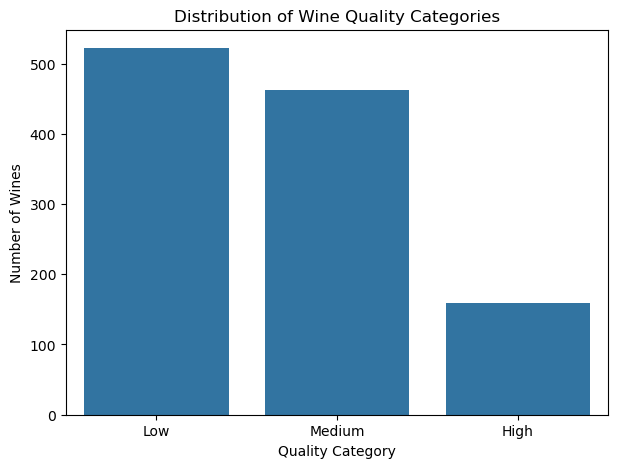

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality_category"
)

plt.xticks(
    [0, 1, 2],
    ["Low", "Medium", "High"]
)

plt.title("Distribution of Wine Quality Categories")
plt.xlabel("Quality Category")
plt.ylabel("Number of Wines")

plt.show()

## Feature Engineering

The original wine quality score ranges from 3 to 8, but the classes are highly imbalanced. In particular, quality scores 3 and 8 contain very few observations. Therefore, the original scores were grouped into three categories:

Low: quality scores 3–5
Medium: quality score 6
High: quality scores 7–8

A three-class classification approach was selected because it reduces the severe class imbalance while preserving more information than a simple binary classification approach.

# Prepare X and y

In [27]:
X = df.drop(
    columns=["quality", "quality_category"]
)

y = df["quality_category"]

In [28]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1143, 11)
y shape: (1143,)


# Test split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the stratification

In [30]:
print("Training set:")
print(y_train.value_counts().sort_index())

print("\nTesting set:")
print(y_test.value_counts().sort_index())

Training set:
quality_category
0    417
1    370
2    127
Name: count, dtype: int64

Testing set:
quality_category
0    105
1     92
2     32
Name: count, dtype: int64


In [31]:
print("Training percentages:")
print(
    (y_train.value_counts(normalize=True) * 100)
    .sort_index()
    .round(2)
)

print("\nTesting percentages:")
print(
    (y_test.value_counts(normalize=True) * 100)
    .sort_index()
    .round(2)
)

Training percentages:
quality_category
0    45.62
1    40.48
2    13.89
Name: proportion, dtype: float64

Testing percentages:
quality_category
0    45.85
1    40.17
2    13.97
Name: proportion, dtype: float64


# Import the ML libraries

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Train Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

# Make predictions using Random Forest

In [34]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:20])

[1 1 2 0 1 1 0 1 1 1 1 1 0 1 1 1 1 2 1 0]


# Random Forest Accuracy

In [35]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7248908296943232


# Random Forest Classification Report

In [36]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.78      0.74      0.76       105
      Medium       0.65      0.73      0.69        92
        High       0.81      0.66      0.72        32

    accuracy                           0.72       229
   macro avg       0.75      0.71      0.72       229
weighted avg       0.73      0.72      0.73       229



# Random Forest Confusion Matrix

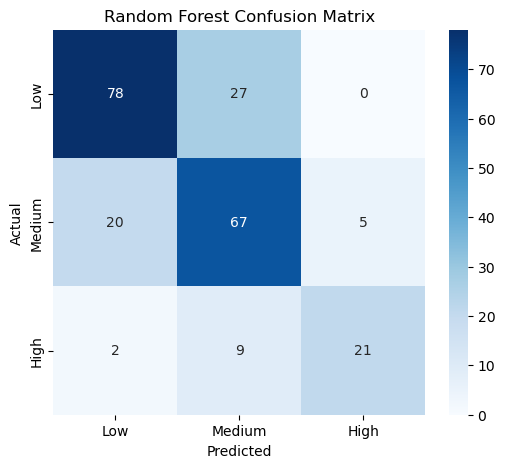

In [37]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

# Train SGD Classifier

In [38]:
sgd_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "sgd",
        SGDClassifier(
            loss="hinge",
            max_iter=2000,
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [39]:
sgd_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sgd',
                 SGDClassifier(class_weight='balanced', max_iter=2000,
                               random_state=42))])

# SGD Predictions

In [40]:
y_pred_sgd = sgd_model.predict(X_test)

print(y_pred_sgd[:20])

[2 2 2 0 2 2 1 2 2 1 2 1 0 0 0 1 2 2 2 0]


# SGD Classification Report

In [41]:
print(
    classification_report(
        y_test,
        y_pred_sgd,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.71      0.72      0.72       105
      Medium       0.48      0.30      0.37        92
        High       0.30      0.59      0.40        32

    accuracy                           0.54       229
   macro avg       0.50      0.54      0.50       229
weighted avg       0.56      0.54      0.53       229



# SGD Confusion Matrix

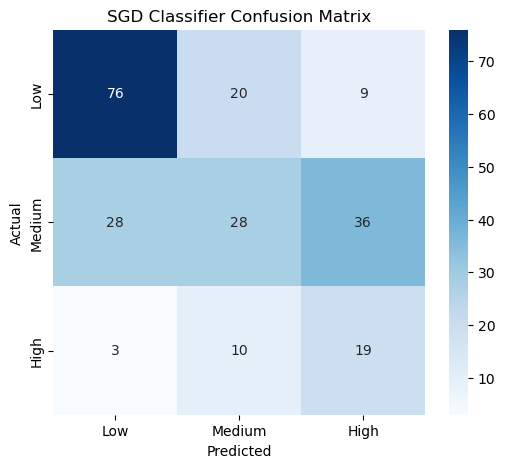

In [42]:
cm_sgd = confusion_matrix(
    y_test,
    y_pred_sgd
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SGD Classifier Confusion Matrix")

plt.show()

# Train SVC

In [43]:
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svc",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=42
        )
    )
])

In [44]:
svc_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(class_weight='balanced', random_state=42))])

# SVC Predictions

In [45]:
y_pred_svc = svc_model.predict(X_test)

print(y_pred_svc[:20])

[1 1 2 0 2 2 0 2 1 1 2 1 0 0 1 1 2 2 2 0]


# SVC Accuracy

In [46]:
svc_accuracy = accuracy_score(
    y_test,
    y_pred_svc
)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.611353711790393


# SVC Classification Report

In [47]:
print(
    classification_report(
        y_test,
        y_pred_svc,
        target_names=["Low", "Medium", "High"]
    )
)

              precision    recall  f1-score   support

         Low       0.75      0.72      0.73       105
      Medium       0.56      0.48      0.52        92
        High       0.41      0.62      0.49        32

    accuracy                           0.61       229
   macro avg       0.57      0.61      0.58       229
weighted avg       0.63      0.61      0.61       229



# SVC Confusion Matrix

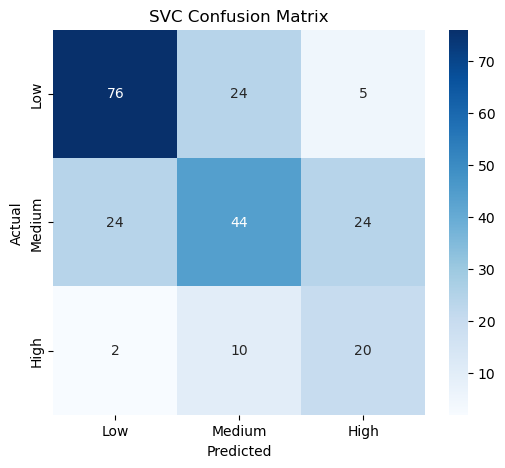

In [48]:
cm_svc = confusion_matrix(
    y_test,
    y_pred_svc
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVC Confusion Matrix")

plt.show()

# Create the comparison table

In [49]:
rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

sgd_report = classification_report(
    y_test,
    y_pred_sgd,
    output_dict=True
)

svc_report = classification_report(
    y_test,
    y_pred_svc,
    output_dict=True
)

In [50]:
print("Random Forest predictions:", "y_pred_rf" in globals())
print("SGD predictions:", "y_pred_sgd" in globals())
print("SVC predictions:", "y_pred_svc" in globals())
   

Random Forest predictions: True
SGD predictions: True
SVC predictions: True


In [51]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)
svc_accuracy = accuracy_score(y_test, y_pred_svc)

print("Random Forest Accuracy:", rf_accuracy)
print("SGD Classifier Accuracy:", sgd_accuracy)
print("SVC Accuracy:", svc_accuracy)

Random Forest Accuracy: 0.7248908296943232
SGD Classifier Accuracy: 0.537117903930131
SVC Accuracy: 0.611353711790393


In [52]:
rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

sgd_report = classification_report(
    y_test,
    y_pred_sgd,
    output_dict=True
)

svc_report = classification_report(
    y_test,
    y_pred_svc,
    output_dict=True
)

In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],

    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],

    "Macro Precision": [
        rf_report["macro avg"]["precision"],
        sgd_report["macro avg"]["precision"],
        svc_report["macro avg"]["precision"]
    ],

    "Macro Recall": [
        rf_report["macro avg"]["recall"],
        sgd_report["macro avg"]["recall"],
        svc_report["macro avg"]["recall"]
    ],

    "Macro F1": [
        rf_report["macro avg"]["f1-score"],
        sgd_report["macro avg"]["f1-score"],
        svc_report["macro avg"]["f1-score"]
    ]
})

comparison.round(3)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.725,0.746,0.709,0.724
1,SGD Classifier,0.537,0.497,0.541,0.495
2,SVC,0.611,0.572,0.609,0.582


In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

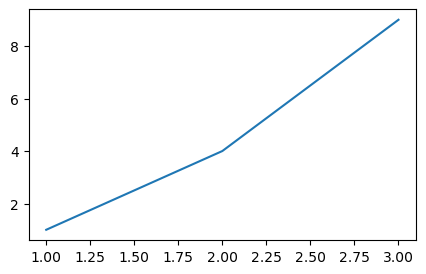

In [55]:
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [56]:
print("df:", "df" in globals())
print("X_train:", "X_train" in globals())
print("rf_model:", "rf_model" in globals())
print("comparison:", "comparison" in globals())

df: True
X_train: True
rf_model: True
comparison: True


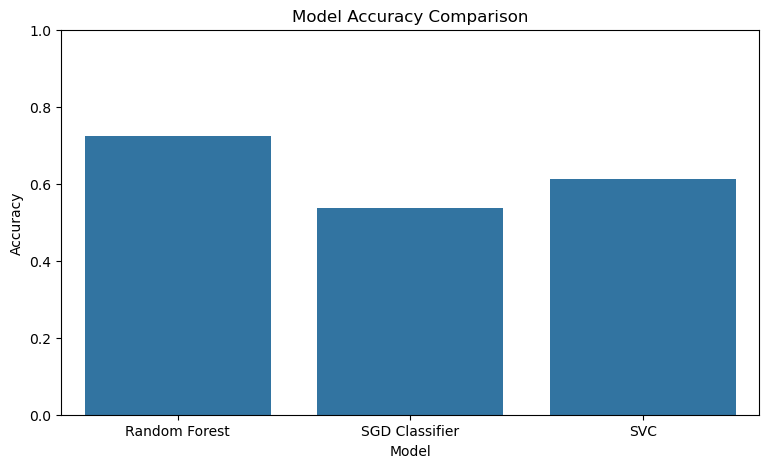

In [57]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

In [58]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.171255
9,sulphates,0.130819
1,volatile acidity,0.105325
2,citric acid,0.099943
6,total sulfur dioxide,0.089432
7,density,0.080411
0,fixed acidity,0.071386
4,chlorides,0.070290
8,pH,0.068263
3,residual sugar,0.057313


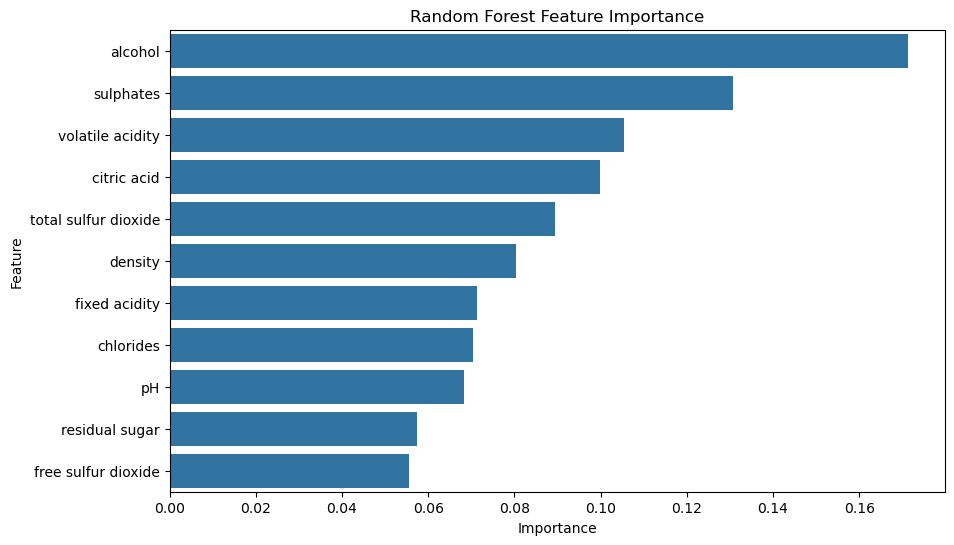

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [60]:
most_important = feature_importance.iloc[0]

print("Most Important Feature:", most_important["Feature"])
print("Importance:", round(most_important["Importance"], 4))

Most Important Feature: alcohol
Importance: 0.1713


In [61]:
best_model = comparison.loc[
    comparison["Macro F1"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 3))
print("Macro F1:", round(best_model["Macro F1"], 3))

Best Model: Random Forest
Accuracy: 0.725
Macro F1: 0.724


## Conclusion

The Wine Quality Prediction project classified wines into three categories: Low, Medium, and High based on their physicochemical properties.

Exploratory data analysis showed that the original quality scores were imbalanced, with quality scores 5 and 6 having considerably more observations than the extreme quality scores. To reduce the effect of this imbalance, the original scores were grouped into three categories.

Three classification models were trained and compared: Random Forest, SGD Classifier, and Support Vector Classifier (SVC). A stratified train-test split was used to preserve the class distribution.

The models were evaluated using accuracy, macro precision, macro recall, macro F1-score, classification reports, and confusion matrices.
| Model          |  Accuracy |  Macro F1 |
| -------------- | --------: | --------: |
| Random Forest  | **72.5%** | **72.4%** |
| SVC            |     61.1% |     58.2% |
| SGD Classifier |     53.7% |     49.5% |

Among the three models, Random Forest performed the best, achieving an accuracy of 72.5% and a macro F1-score of 72.4%.
Therefore, Random Forest is the most suitable model among the tested classifiers for this dataset. Its feature importance analysis also provides insight into which physicochemical properties contribute most to wine quality prediction



# Testing a new wine

In [62]:
def predict_wine_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):
    
    sample = pd.DataFrame([[
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    ]], columns=X.columns)

    prediction = rf_model.predict(sample)[0]

    labels = {
        0: "Low",
        1: "Medium",
        2: "High"
    }

    return labels[prediction]

In [63]:
result = predict_wine_quality(
    7.4,
    0.70,
    0.00,
    1.9,
    0.076,
    11,
    34,
    0.9978,
    3.51,
    0.56,
    9.4
)

print("Predicted Wine Quality:", result)

Predicted Wine Quality: Low
